In [34]:
!pip install gseapy


In [35]:
print(df.head())

      Ref ID                      locus     Control Treated  FPKM_Control  \
0  NM_000016     chr1:75724346-75763678  NHHW161152      U1       6.42683   
1  NM_000017  chr12:120725737-120740008  NHHW161152      U1       8.22129   
2  NM_000018      chr17:7189890-7225267  NHHW161152      U1     248.72800   
3  NM_000019  chr11:108121530-108148164  NHHW161152      U1      22.71930   
4  NM_000020    chr12:51907417-51923361  NHHW161152      U1      11.51530   

     FPKM_U1  log2FC U1 Vs C  test_stat  p_value        q_value Gene Symbol  \
0    9.35583           0.542      6.621    0.000  1.000000e-300       ACADM   
1    9.11939           0.150      1.635    0.044   5.200000e-02       ACADS   
2  105.57200          -1.236    -34.901    0.000  1.000000e-300      ACADVL   
3   53.62050           1.239     29.579    0.000  1.000000e-300       ACAT1   
4   43.36210           1.913     39.739    0.000  1.000000e-300      ACVRL1   

   minus_log10_p  minus_log10_q  
0            inf     300.000

C:\Users\bim12\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


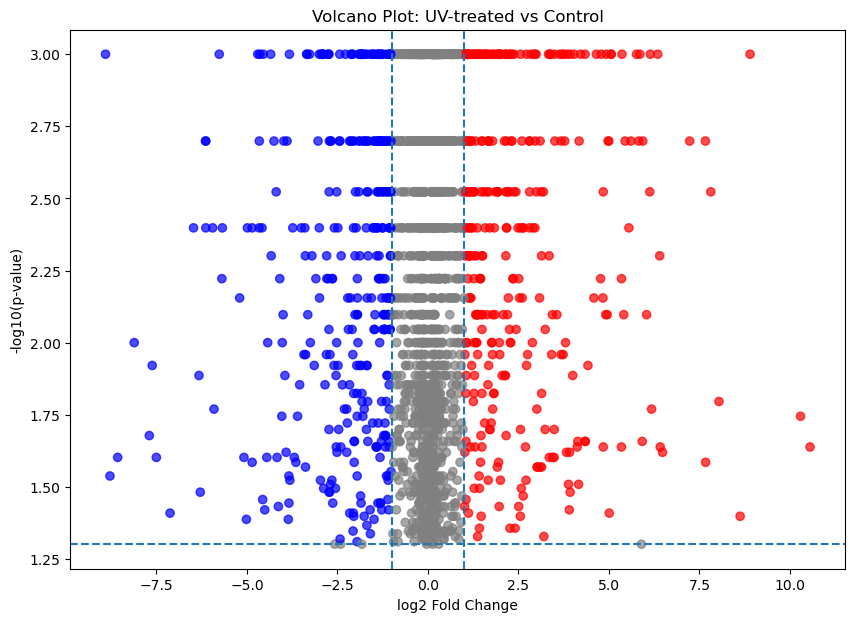

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# 기준 설정
p_threshold = 0.05
fc_threshold = 1

# significance 계산
df["minus_log10_p"] = -np.log10(df["p_value"])

# 색상 분류
colors = []

for i in range(len(df)):
    
    log2fc = df.iloc[i]["log2FC U1 Vs C"]
    pval = df.iloc[i]["p_value"]
    
    if pval < p_threshold and log2fc > fc_threshold:
        colors.append("red")      # upregulated
    
    elif pval < p_threshold and log2fc < -fc_threshold:
        colors.append("blue")     # downregulated
    
    else:
        colors.append("gray")     # non-significant

# volcano plot 생성
plt.figure(figsize=(10, 7))

plt.scatter(
    df["log2FC U1 Vs C"],
    df["minus_log10_p"],
    c=colors,
    alpha=0.7
)

# threshold line 추가
plt.axvline(x=fc_threshold, linestyle="--")
plt.axvline(x=-fc_threshold, linestyle="--")
plt.axhline(y=-np.log10(p_threshold), linestyle="--")

# label
plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot: UV-treated vs Control")

plt.show()

In [37]:
!pip install adjustText

In [38]:
from adjustText import adjust_text

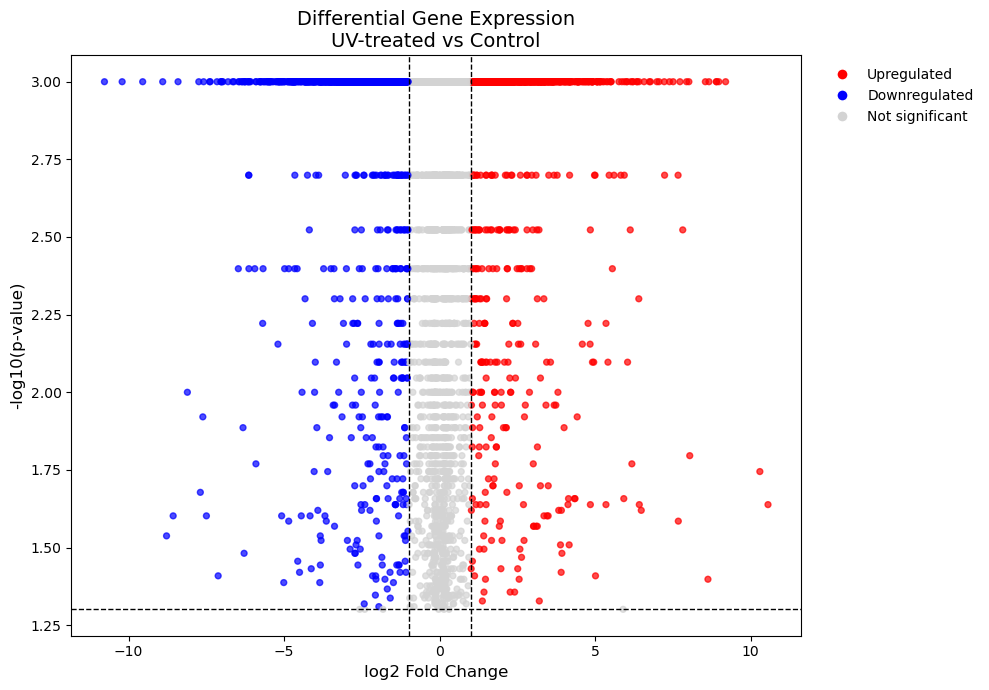

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==========================================
# Parameters
# ==========================================
p_threshold = 0.05
fc_threshold = 1

# ==========================================
# Plot용 p-value
# (시각화용으로만 0을 0.001로 변경)
# ==========================================
plot_p = df["p_value"].replace(0, 0.001)

y = -np.log10(plot_p)

# ==========================================
# Color
# ==========================================
colors = np.where(
    (df["p_value"] < p_threshold) &
    (df["log2FC U1 Vs C"] >= fc_threshold),
    "red",
    np.where(
        (df["p_value"] < p_threshold) &
        (df["log2FC U1 Vs C"] <= -fc_threshold),
        "blue",
        "lightgray"
    )
)

# ==========================================
# Plot
# ==========================================
plt.figure(figsize=(10,7))

plt.scatter(
    df["log2FC U1 Vs C"],
    y,
    c=colors,
    s=18,
    alpha=0.7
)

# Threshold
plt.axvline(fc_threshold,
            color="black",
            linestyle="--",
            linewidth=1)

plt.axvline(-fc_threshold,
            color="black",
            linestyle="--",
            linewidth=1)

plt.axhline(-np.log10(p_threshold),
            color="black",
            linestyle="--",
            linewidth=1)

# Labels
plt.xlabel("log2 Fold Change", fontsize=12)
plt.ylabel("-log10(p-value)", fontsize=12)
plt.title("Differential Gene Expression\nUV-treated vs Control",
          fontsize=14)

# Legend
legend_elements = [
    Line2D([0],[0], marker='o', color='w',
           label='Upregulated',
           markerfacecolor='red',
           markersize=8),

    Line2D([0],[0], marker='o', color='w',
           label='Downregulated',
           markerfacecolor='blue',
           markersize=8),

    Line2D([0],[0], marker='o', color='w',
           label='Not significant',
           markerfacecolor='lightgray',
           markersize=8)
]

plt.legend(
    handles=legend_elements,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()

plt.savefig(
    "Volcano_plot_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:

import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt

# =========================
# 1. DEG 파일 불러오기
# =========================
deg_file = "GSE119009_DEG_U1_Vs_Control_Original.csv"
df = pd.read_csv(deg_file)

# 컬럼명 확인
print(df.columns)

# =========================
# 2. 컬럼명 설정 (네 파일에 맞게 수정)
# =========================
gene_col = "Gene Symbol"
logfc_col = "log2FC U1 Vs C"
padj_col = "q_value"

# =========================
# 3. DEG 필터링
# 기준은 필요에 따라 바꿔도 됨
# =========================
sig = df[
    (df[padj_col] < 0.05) &
    (abs(df[logfc_col]) >= 1)
].copy()

up_genes = sig[sig[logfc_col] > 0][gene_col].dropna().astype(str).unique().tolist()
down_genes = sig[sig[logfc_col] < 0][gene_col].dropna().astype(str).unique().tolist()

print("Upregulated genes:", len(up_genes))
print("Downregulated genes:", len(down_genes))

# =========================
# 4. GO Biological Process enrichment
# =========================
# organism은 사람 데이터면 "Human"
# gene_sets는 GO_Biological_Process_2023 추천
# =========================
enr_up = gp.enrichr(
    gene_list=up_genes,
    gene_sets="GO_Biological_Process_2023",
    organism="human",
    outdir="go_up_results",
    cutoff=0.05
)

enr_down = gp.enrichr(
    gene_list=down_genes,
    gene_sets="GO_Biological_Process_2023",
    organism="human",
    outdir="go_down_results",
    cutoff=0.05
)


# 결과 테이블 확인
print(enr_up.results.head())
print(enr_down.results.head())

# csv로 저장
enr_up.results.to_csv("GO_upregulated_results.csv", index=False)
enr_down.results.to_csv("GO_downregulated_results.csv", index=False)



Index(['Ref ID', 'locus', 'Control', 'Treated', 'FPKM_Control', 'FPKM_U1',
       'log2FC U1 Vs C', 'test_stat', 'p_value', 'q_value', 'Gene Symbol'],
      dtype='object')
Upregulated genes: 1998
Downregulated genes: 2784
                     Gene_set  \
0  GO_Biological_Process_2023   
1  GO_Biological_Process_2023   
2  GO_Biological_Process_2023   
3  GO_Biological_Process_2023   
4  GO_Biological_Process_2023   

                                                Term Overlap   P-value  \
0  Branched-Chain Amino Acid Catabolic Process (G...    9/17  0.000011   
1  Branched-Chain Amino Acid Metabolic Process (G...    8/15  0.000033   
2  Regulation Of Basement Membrane Organization (...     4/5  0.000457   
3          acetyl-CoA Metabolic Process (GO:0006084)    7/16  0.000498   
4  Cellular Response To Prostaglandin Stimulus (G...     5/9  0.000883   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.044446            0                     0   10.177

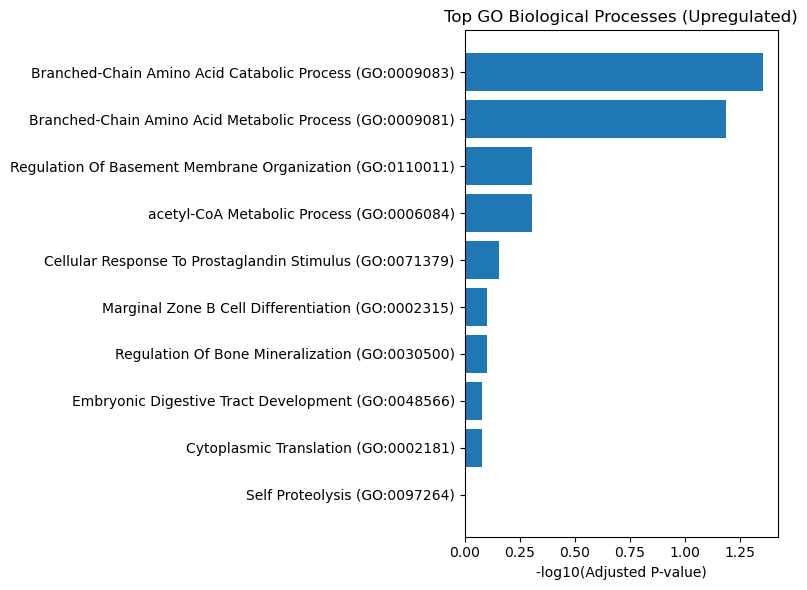

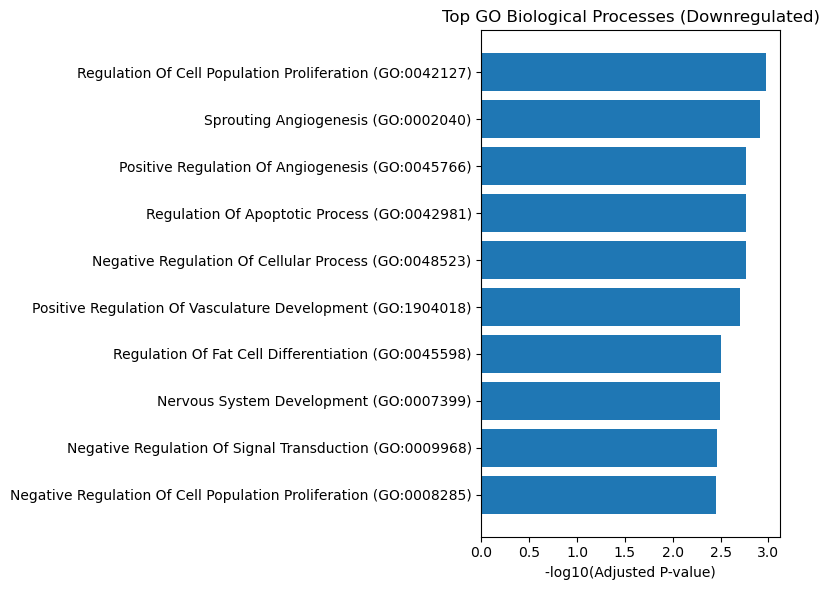

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# GO enrichment 결과 불러오기
# ==============================
up = pd.read_csv("GO_upregulated_results.csv")
down = pd.read_csv("GO_downregulated_results.csv")

# ==============================
# 상위 10개 GO term 선택
# (Adjusted P-value 기준)
# ==============================
up = up.sort_values("Adjusted P-value").head(10)
down = down.sort_values("Adjusted P-value").head(10)

# -log10(p-value) 계산
up["Score"] = -np.log10(up["Adjusted P-value"])
down["Score"] = -np.log10(down["Adjusted P-value"])

# ==============================
# Upregulated GO plot
# ==============================
plt.figure(figsize=(8,6))

plt.barh(up["Term"], up["Score"])

plt.xlabel("-log10(Adjusted P-value)")
plt.title("Top GO Biological Processes (Upregulated)")
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("GO_upregulated_barplot.png", dpi=300)

plt.show()

# ==============================
# Downregulated GO plot
# ==============================
plt.figure(figsize=(8,6))

plt.barh(down["Term"], down["Score"])

plt.xlabel("-log10(Adjusted P-value)")
plt.title("Top GO Biological Processes (Downregulated)")
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("GO_downregulated_barplot.png", dpi=300)

plt.show()

In [48]:
print(df.columns)

Index(['Ref ID', 'locus', 'Control', 'Treated', 'FPKM_Control', 'FPKM_U1',
       'log2FC U1 Vs C', 'test_stat', 'p_value', 'q_value', 'Gene Symbol'],
      dtype='object')


In [49]:
print(df["Gene Symbol"].head())

0     ACADM
1     ACADS
2    ACADVL
3     ACAT1
4    ACVRL1
Name: Gene Symbol, dtype: object


In [50]:
df[["Control","Treated","FPKM_Control","FPKM_U1"]].head()

,Control,Treated,FPKM_Control,FPKM_U1
0,NHHW161152,U1,6.42683,9.35583
1,NHHW161152,U1,8.22129,9.11939
2,NHHW161152,U1,248.72800,105.57200
3,NHHW161152,U1,22.71930,53.62050
4,NHHW161152,U1,11.51530,43.36210


In [52]:
# ============================
# Representative genes from GO
# ============================

process_genes = {

    "Metabolism": up.loc[0, "Genes"].split(";")[:5],

    "Cell proliferation": down.loc[0, "Genes"].split(";")[:5],

    "Angiogenesis": down.loc[1, "Genes"].split(";")[:5],

    "Apoptosis": down.loc[3, "Genes"].split(";")[:5]

}

print(process_genes)

{'Metabolism': ['MCCC2', 'ALDH6A1', 'HIBADH', 'IVD', 'BCKDHB'], 'Cell proliferation': ['IFITM1', 'TFRC', 'CSF1', 'RTKN2', 'SCX'], 'Angiogenesis': ['SEMA5A', 'RAMP2', 'EGR3', 'TGFB1', 'YJEFN3'], 'Apoptosis': ['MTCH1', 'FCMR', 'TFRC', 'SCX', 'COMP']}


In [53]:
process_genes["ECM"] = [
    "COL1A1",
    "COL1A2",
    "COL3A1",
    "FN1",
    "MMP1"
]

process_genes["Inflammation"] = [
    "IL6",
    "IL1B",
    "CXCL8",
    "CCL2",
    "TNF"
]

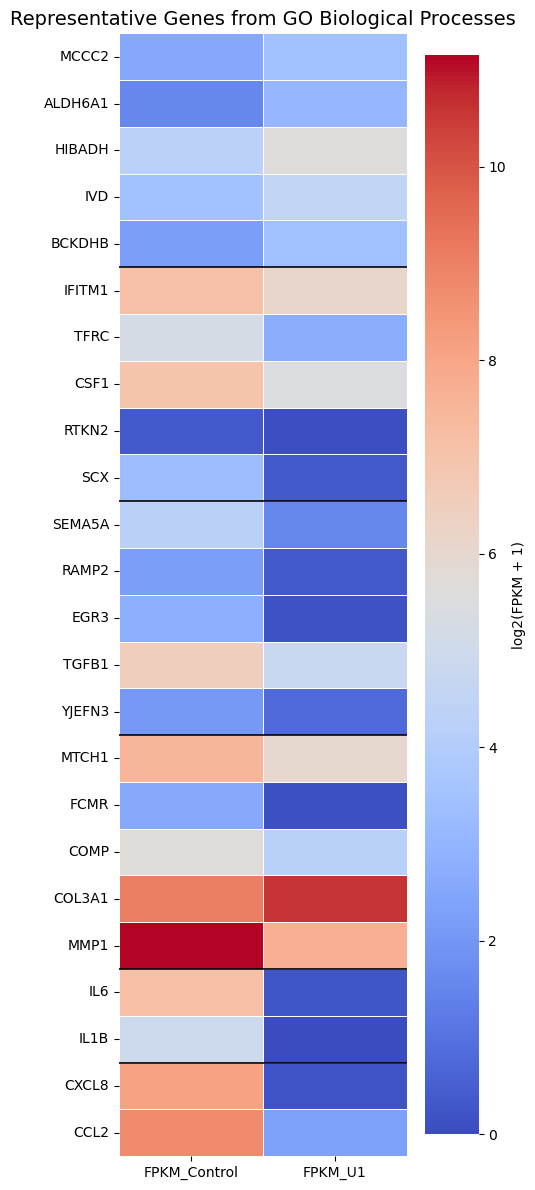

In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# gene 순서
ordered_genes = []

for genes in process_genes.values():
    ordered_genes.extend(genes)

# 중복 제거 (순서 유지)
ordered_genes = list(dict.fromkeys(ordered_genes))

heatmap_df = (
    df[df["Gene Symbol"].isin(ordered_genes)]
    .drop_duplicates(subset="Gene Symbol")
    .set_index("Gene Symbol")
)

heatmap_df = heatmap_df.reindex(
    [g for g in ordered_genes if g in heatmap_df.index]
)

expression = np.log2(
    heatmap_df[["FPKM_Control","FPKM_U1"]] + 1
)

plt.figure(figsize=(5,12))

ax = sns.heatmap(
    expression,
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"label":"log2(FPKM + 1)"}
)

plt.title(
    "Representative Genes from GO Biological Processes",
    fontsize=14
)

plt.xlabel("")
plt.ylabel("")

# process 구분선
current = 0

for process, genes in process_genes.items():

    existing = [g for g in genes if g in expression.index]

    current += len(existing)

    if current < len(expression):

        ax.hlines(
            current,
            *ax.get_xlim(),
            colors="black",
            linewidth=1.2
        )

plt.tight_layout()

plt.savefig(
    "Heatmap_GO_expression.png",
    dpi=300
)

plt.show()

In [55]:
import pandas as pd

plot_data = []

for process, genes in process_genes.items():

    subset = df[df["Gene Symbol"].isin(genes)]

    for _, row in subset.iterrows():

        plot_data.append({
            "Process": process,
            "log2FC": row["log2FC U1 Vs C"]
        })

plot_df = pd.DataFrame(plot_data)

plot_df.head()

,Process,log2FC
0,Metabolism,1.353
1,Metabolism,1.137
2,Metabolism,1.943
3,Metabolism,1.022
4,Metabolism,1.375


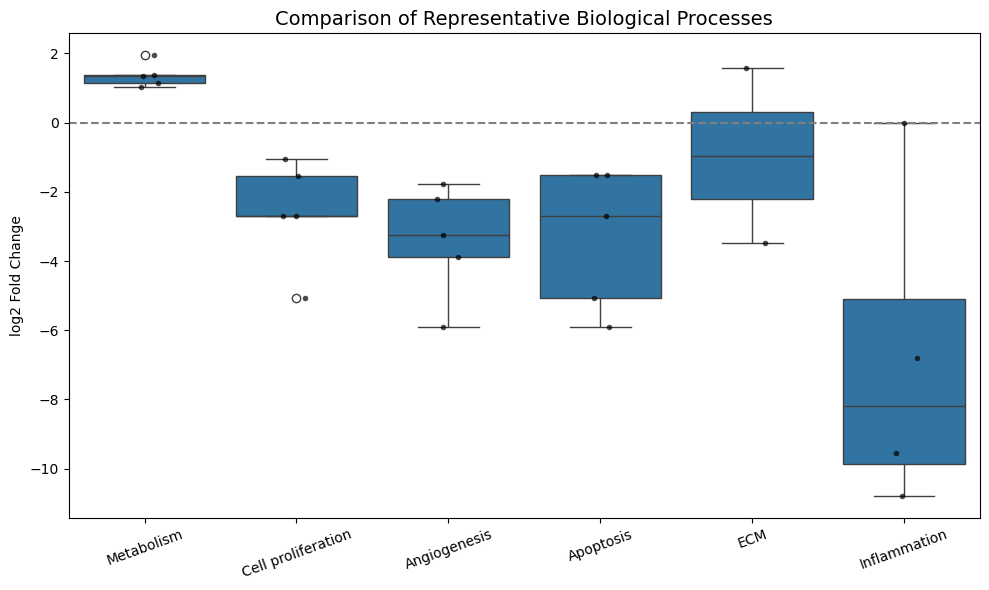

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=plot_df,
    x="Process",
    y="log2FC"
)

sns.stripplot(
    data=plot_df,
    x="Process",
    y="log2FC",
    color="black",
    size=4,
    alpha=0.7
)

plt.axhline(0, color="gray", linestyle="--")

plt.title(
    "Comparison of Representative Biological Processes",
    fontsize=14
)

plt.ylabel("log2 Fold Change")

plt.xlabel("")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "Group_comparison_boxplot.png",
    dpi=300
)

plt.show()

In [1]:
import os 
os.getcwd()

'C:\\Users\\bim12\\anaconda_projects\\UV_gene_expression'

In [2]:
os.listdir()

['.ipynb_checkpoints',
 'figures',
 'Github_rna_seq_photoaging.ipynb',
 'GO_downregulated_barplot.png',
 'GO_downregulated_results.csv',
 'go_down_results',
 'GO_upregulated_barplot.png',
 'GO_upregulated_results.csv',
 'go_up_results',
 'Group_comparison_boxplot.png',
 'GSE119009_DEG_U1_Vs_Control_Original.csv',
 'GSE119009_DEG_U1_Vs_Control_Original.xlsx',
 'GSE119009_series_matrix.txt.gz',
 'GSE284483_series_matrix.txt.gz',
 'Heatmap_GO_expression.png',
 'rna_seq_photoaging-Copy1.ipynb',
 'rna_seq_photoaging-upd.ipynb',
 'rna_seq_photoaging.ipynb',
 'Untitled.ipynb',
 'Volcano_plot.png',
 'Volcano_plot_final.png']

In [3]:
import os
os.startfile(os.getcwd())